In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt                     
import seaborn as sns


In [16]:
df = pd.read_csv("data_science_job.csv")
df.head(4)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0


In [17]:
df.info()       

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [18]:
df_mean= ((df.isna().sum())/len(df))*100
df_mean

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [19]:
df.shape

(19158, 13)

In [20]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [21]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
8941,0.926,Full time course,High School,6.0,37.0
17197,0.802,no_enrollment,High School,12.0,4.0
1145,0.624,Full time course,High School,3.0,242.0
8232,0.920,no_enrollment,Primary School,8.0,180.0
8714,0.920,Full time course,Graduate,0.0,2.0


In [22]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [23]:
#  in pandas calculates the percentage (or fraction) of rows that are complete (contain no missing values/NaNs) within a 
# specific subset of columns.
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [24]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

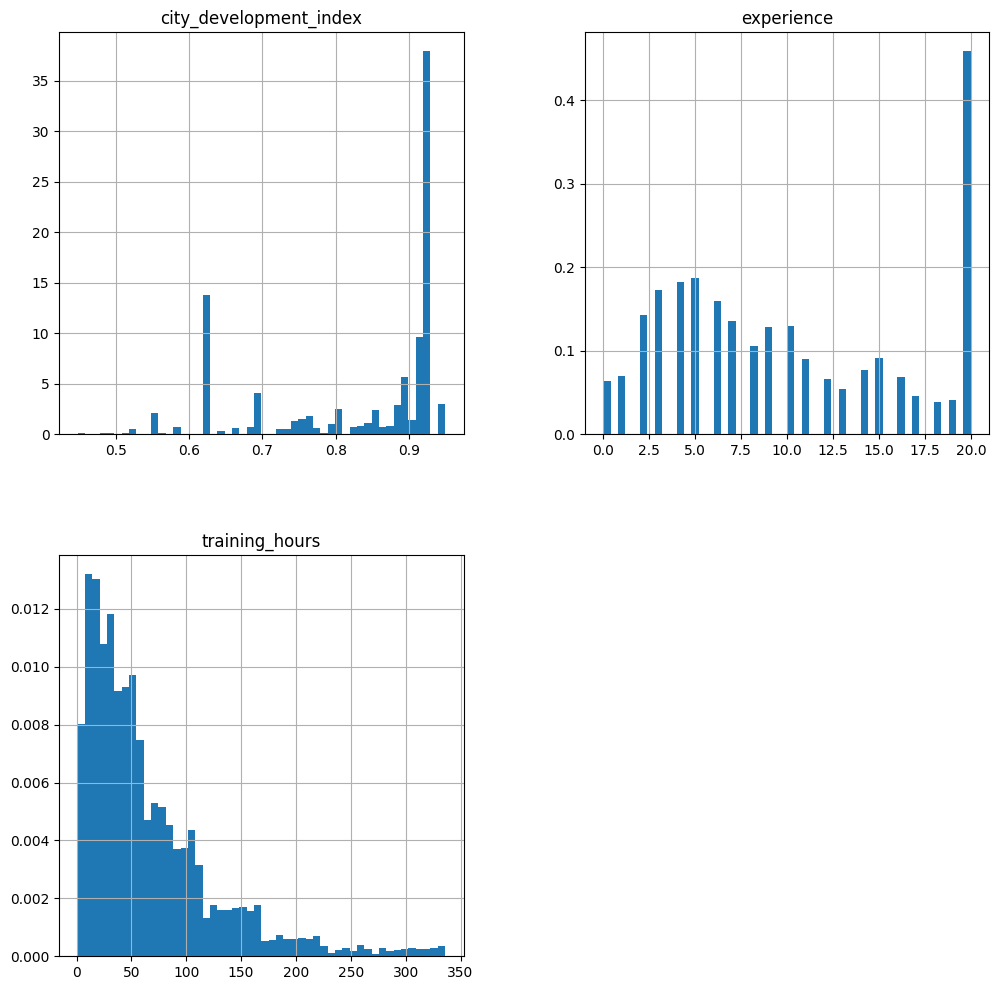

In [25]:

new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

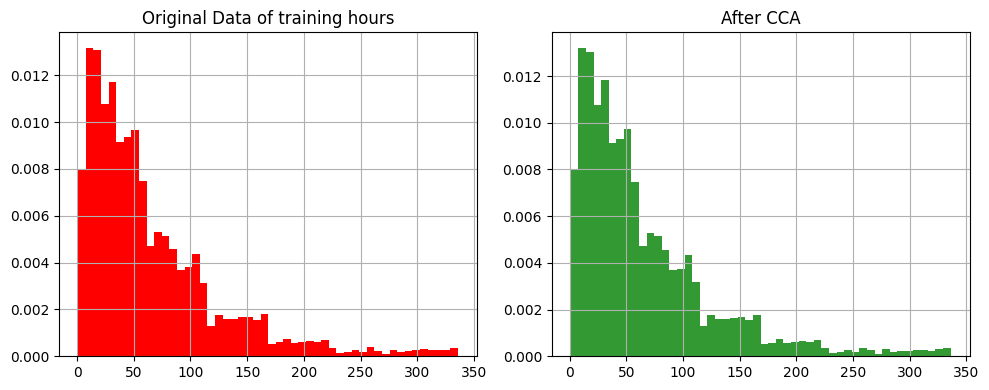

In [26]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(121)

df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')
plt.title('Original Data of training hours')


ax1 = fig.add_subplot(122)
new_df['training_hours'].hist(bins=50, ax=ax1, color='green', density=True, alpha=0.8)
plt.title("After CCA")

fig.tight_layout()
plt.show()

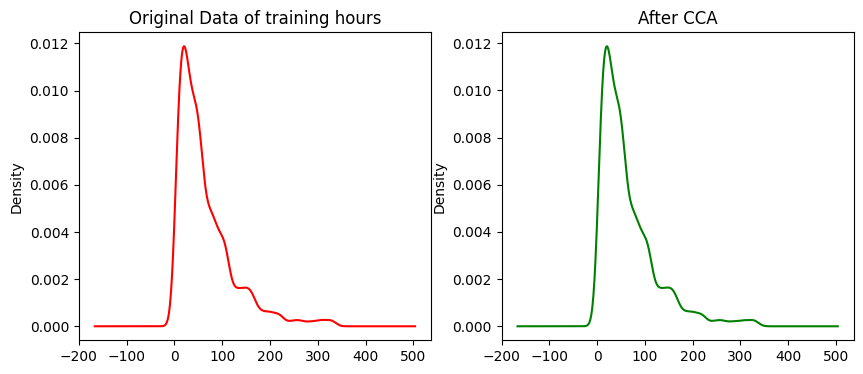

In [27]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(121)

# original data
df['training_hours'].plot.density(color='red')
plt.title('Original Data of training hours')    
ax = fig.add_subplot(122)

# data after cca
new_df['training_hours'].plot.density(color='green')
plt.title("After CCA")
plt.show()

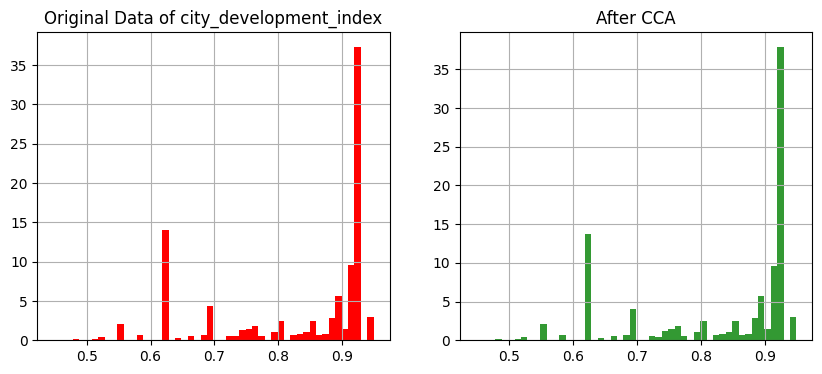

In [28]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(121)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')
plt.title('Original Data of city_development_index')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
ax = fig.add_subplot(122)
plt.title("After CCA")

new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)
plt.show()

In [31]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']
temp



,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


<Axes: xlabel='enrolled_university'>

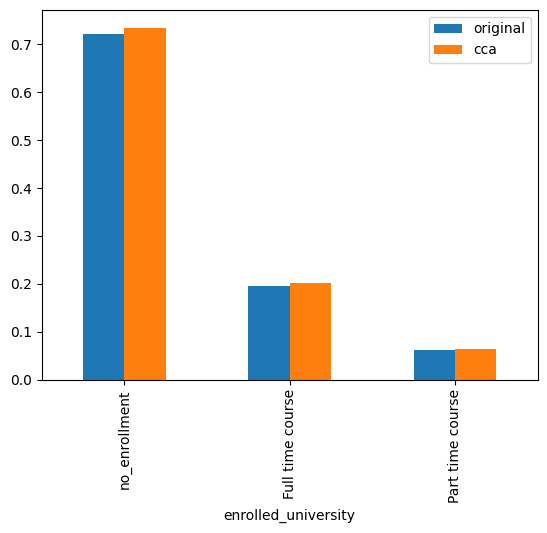

In [32]:
temp.plot.bar()

In [ ]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


<Axes: xlabel='education_level'>

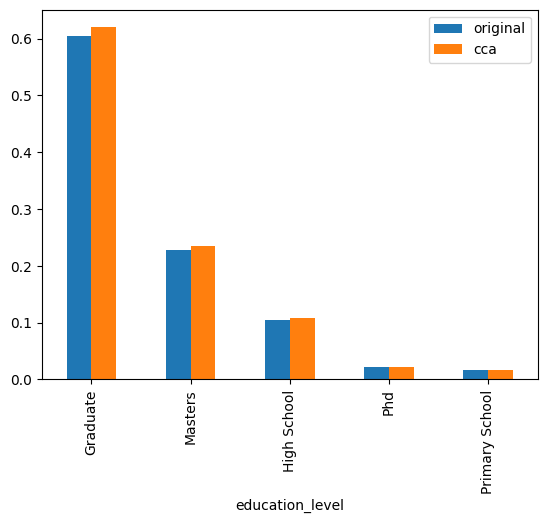

In [34]:
temp.plot.bar()